Imports mainly used

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Function Definition and testing

In [3]:
def f(x):
    return 4*x**2 + 3*x - 5

In [4]:
f(3)

40

Plotting function

In [5]:
xs = np.arange(-5,5,0.25)
ys = f(xs)

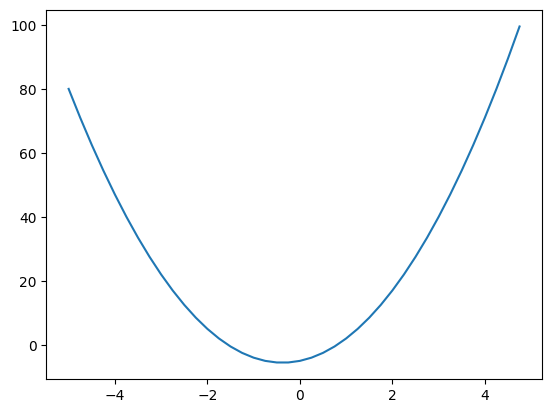

In [6]:
plt.plot(xs,ys)

Derivative calculation(normal derivative)

In [7]:
# derivative
h = 0.001
def f_prime(x):
    return (f(x + h) - f(x))/h
print(f_prime(3))

27.00399999999803


Expressing the function that provides an expression graph

In [8]:
a=2
b=-3
c=10

d=a*b+c
print(d)

4


Partial derivatives(derivates with respect to a single variable)

In [9]:
a=2
b=-3
c=10

a+= h
d1 = a*b+c
slope_a = (d1-d)/h

a-=h
b+=h
d2 = a*b+c
slope_b = (d2-d)/h

b-=h
c+=h
d3 = a*b+c
slope_c = (d3-d)/h

print('slope_a', slope_a)
print('slope_b', slope_b)
print('slope_c', slope_c)

slope_a -3.0000000000001137
slope_b 1.9999999999997797
slope_c 0.9999999999994458


Initializing a Value object

In [88]:
class Value():
    def __init__(self, data, _children=(), _op = '', label=''):
        self.data = data
        self._prev = set(_children)
        self._backward = lambda: None
        self._op = _op
        self.grad = 0
        self.label = label
    def __repr__(self):
        return f"Value = {self.data}"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        self = self if isinstance(self, Value) else Value(self)
        sum = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += sum.grad * 1.0
            other.grad += sum.grad * 1.0
        sum._backward = _backward
        return sum
    def __neg__(self):
        return self * -1
    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self + (-other)
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        product = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += product.grad * other.data
            other.grad += product.grad * self.data
        product._backward = _backward
        return product
    def __pow__(self, other):
        # Ensure the exponent is an int or float, not a Value object
        assert isinstance(other, (int, float)), "Only supporting int/float powers for now"
        
        out = Value(self.data ** other, (self,), f'**{other}')
        
        def _backward():
            # d/dx (x^n) = n * x^(n-1)
            self.grad += (other * (self.data ** (other - 1))) * out.grad
            
        out._backward = _backward
        return out
    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other
    def tanh(self):
        e2x = math.exp(2* self.data)
        t = (e2x - 1)/(e2x + 1)
        o = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * o.grad
        o._backward = _backward
        return o
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        print(topo)
        for node in reversed(topo):
            node._backward()

In [44]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label =n._op)
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)

    return dot

In [49]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

O = n.tanh(); O.label = 'O'

[Value = 6.881373587019543, Value = 1.0, Value = 0.0, Value = 0.0, Value = -3.0, Value = 2.0, Value = -6.0, Value = -6.0, Value = 0.8813735870195432, Value = 0.7071067811865476]


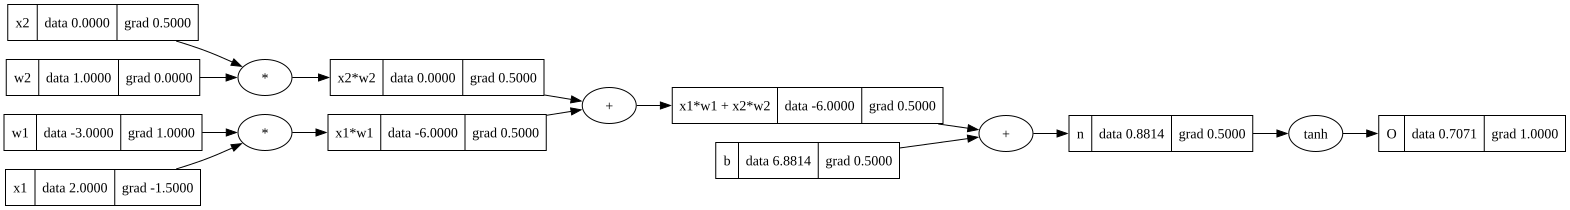

In [50]:
O.backward()
draw_dot(O)

In [53]:
import torch
import random

x1 = torch.tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.tensor([1.0]).double(); w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
O = torch.tanh(n)

print(O.data.item())
O.backward()

print(f"x1 grad = {x1.grad.item()}")
print(f"w1 grad = {w1.grad.item()}")
print(f"x2 grad = {x2.grad.item()}")
print(f"w2 grad = {w2.grad.item()}")

0.7071066904050358
x1 grad = -1.5000003851533106
w1 grad = 1.0000002567688737
x2 grad = 0.5000001283844369
w2 grad = 0.0


In [92]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self, x):
        act = sum((wi * xi for wi,xi in zip(self.w, x)), self.b)
        flatten_act = act.tanh()
        return flatten_act
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

41


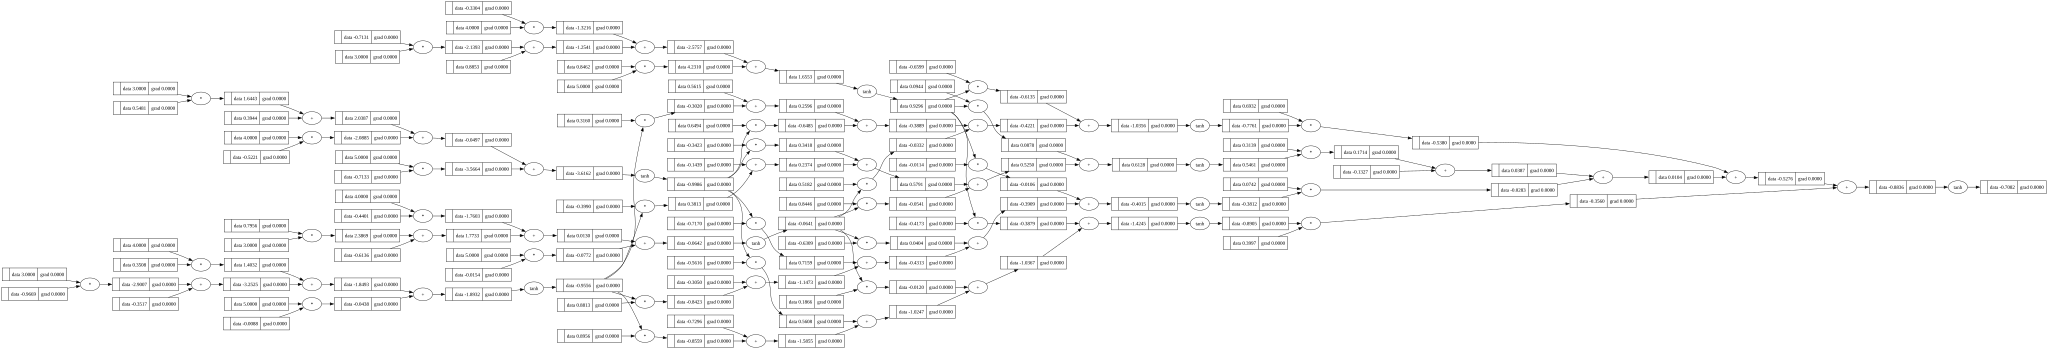

In [96]:
x = [3.0,4.0,5.0]
net = MLP(3, [4,4,1])
net(x)

print(len(net.parameters()))

draw_dot(net(x))

[Value = -0.09548277207097887, Value = 0.2480732943210663, Value = -0.749517266607822, Value = -0.09863746628258548]
Value = 4.027515333949191
[Value = -1, Value = -1.0, Value = 1.0, Value = -0.417251222605141, Value = -0.3304046853095992, Value = 1.0, Value = -0.3304046853095992, Value = 0.5, Value = -0.7131055340080379, Value = -0.35655276700401894, Value = 0.8852539246691118, Value = 0.5287011576650928, Value = 0.19829647235549364, Value = 0.8461960874731245, Value = 1.0, Value = 0.8461960874731245, Value = 1.044492559828618, Value = 0.7796559441174801, Value = -0.32531239589438404, Value = 0.5, Value = 0.7956404065959282, Value = 0.3978202032979641, Value = -0.6135812631801032, Value = -0.21576105988213912, Value = 1.0, Value = -0.4400818069142367, Value = -0.4400818069142367, Value = -0.6558428667963758, Value = -0.015436846795804593, Value = 1.0, Value = -0.015436846795804593, Value = -0.6712797135921804, Value = -0.5858210464490929, Value = 0.18664468477826301, Value = -0.109340

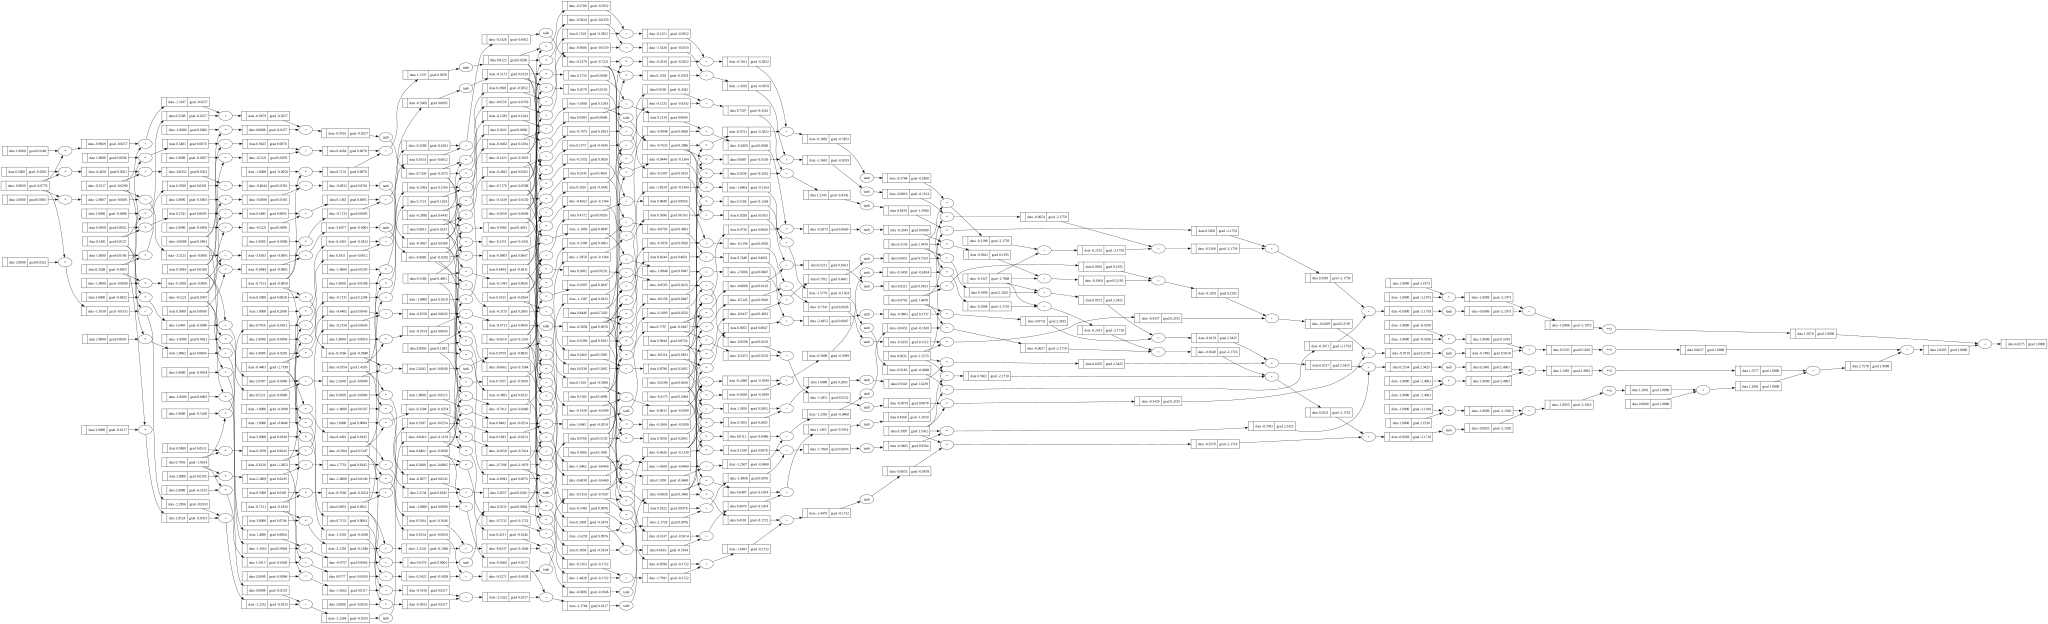

In [97]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

ypred = [net(x) for x in xs]
print(ypred)

loss = sum((yp - yg)**2 for yp, yg in zip(ypred, ys))
print(loss)
loss.backward()
draw_dot(loss)

In [ ]:
for p in net.parameters():
    p.data -= 0.01 * p.grad

In [99]:
ypred = [net(x) for x in xs]
print(ypred)

loss = sum((yp - yg)**2 for yp, yg in zip(ypred, ys))
print(loss)
loss.backward()

[Value = 0.02928974696287579, Value = 0.2915862264220683, Value = -0.731689218977545, Value = 0.0023790282054516063]
Value = 3.677711654211775
[Value = -1, Value = 1.0, Value = -1.0, Value = -1.0, Value = 0.8482937907403741, Value = -0.8482937907403741, Value = 0.8852326122299076, Value = -0.7112794970158334, Value = 1.0, Value = -0.7112794970158334, Value = 0.1739531152140742, Value = -0.33275168668060373, Value = 1.0, Value = -0.33275168668060373, Value = -0.15879857146652954, Value = -1.0070923622069037, Value = -0.7645567141675097, Value = -0.4197147751456812, Value = 0.3208957493729372, Value = 0.184959731696658, Value = -1.0, Value = -0.02994224389012742, Value = 0.02994224389012742, Value = 1.0, Value = -0.41288239607578553, Value = -0.41288239607578553, Value = 1.0, Value = 0.8152545528021896, Value = 0.8152545528021896, Value = -0.6007277858797654, Value = 0.21452676692242423, Value = -0.1983556291533613, Value = -0.16841338526323388, Value = -0.16683900444383942, Value = -0.0

In [ ]:
epochs = 50
for i in range(epochs):
    ypred = [net(x) for x in xs]
    print(ypred)

    loss = sum((yp - yg)**2 for yp, yg in zip(ypred, ys))
    print(f'loss = {loss}')
    for p in net.parameters():
        p.grad = 0.0
    loss.backward()

    for p in net.parameters():
        p.data -= 0.01 * p.grad

[Value = 0.9999999998888693, Value = -0.9862683573981516, Value = -0.9971137267579632, Value = 0.9704531423661457]
loss = Value = 0.0010699053778078535
[Value = 1.0, Value = 3.20147266898405, Value = 3.20147266898405, Value = 1.9949278624768134, Value = 5.1964005314608634, Value = 1.0, Value = -2.3352357003152604, Value = -2.3352357003152604, Value = 2.861164831145603, Value = -1.0, Value = 2.600588335569422, Value = -2.600588335569422, Value = 0.2605764955761809, Value = 0.25483466931671617, Value = -3.982038931172663, Value = -1.0147615742316756, Value = -1.0, Value = -1.3386688345965143, Value = 1.3386688345965143, Value = 1.0, Value = -0.8308610574514051, Value = -0.8308610574514051, Value = 1.0, Value = -0.03595165804290466, Value = -0.03595165804290466, Value = -0.11302933661560499, Value = -0.14898099465850967, Value = -0.9798420521099148, Value = 0.3588267824865995, Value = 0.3441802139209456, Value = 0.16650782824141758, Value = 0.05730869994364317, Value = 1.7410701234872885,